In [12]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

from datetime import time as dttime
from datetime import datetime
from zoneinfo import ZoneInfo
import numpy as np
from scipy.signal import welch
from scipy import signal, stats
from tqdm import tqdm
import pickle
from joblib import Parallel, delayed
COL_PAL = {'Pre-DBS': '#ffe900', 'Hypomanic': '#ff0000', 'Non-Responder': '#ffb900', 'Responder': '#0000ff', 'Unknown': '#808080', 'Non-responder': '#ffb900'}

import os
import math

PATH_ = 'df_for_paper_processed.parq'

In [ ]:
df = pd.read_parquet(PATH_)
df.columns.values

In [28]:
"""Per-day spectral / Hjorth features from resampled LFP windows."""

from __future__ import annotations

import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import welch
from tqdm import tqdm

RESAMPLE_RULE = "30min"
BINS_PER_HOUR = 2          # implied by RESAMPLE_RULE
HOURS_PER_BIN = 1 / BINS_PER_HOUR
KEEP_STATES = ("Pre-DBS", "Responder", "Non-responder")   # drop Disinhibited / Transition
TARGET_PERIODS_H = (6, 12, 24)

# Channels that get the full z-score -> Welch -> Hjorth treatment.
LFP_CHANNELS = {
    "left": "lfp_left_OvER_interpolate_z_scored",
    "right": "lfp_right_OvER_interpolate_z_scored",
}
# Channels that are only averaged over the window (never z-scored, never Welch'd).
# key = output feature name, value = source column
MEAN_CHANNELS = {
    "delta_lfp_left_OvER_interpolate_dayR2": "delta_lfp_left_OvER_interpolate_R2",
}


def _welch_periods(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Welch PSD of a unit-rate series, re-expressed on a period (hours) axis.

    Returns (periods_h, pxx) sorted by *descending* frequency, i.e. ascending index
    = ascending period, with the DC bin dropped.
    """
    f, pxx = welch(x, fs=1.0, nperseg=len(x))
    periods_h = (HOURS_PER_BIN / f[1:])[::-1]
    return periods_h, pxx[1:][::-1]


def _period_idx(periods_h: np.ndarray, target_h: float, rtol: float = 1e-3) -> int | None:
    """Index of the Welch bin closest to `target_h` hours, or None if no bin is close."""
    i = int(np.abs(periods_h - target_h).argmin())
    return i if abs(periods_h[i] - target_h) <= rtol * target_h else None


def _hjorth(x: np.ndarray) -> tuple[float, float, float]:
    """Standard Hjorth activity / mobility / complexity."""
    dx = np.diff(x)
    ddx = np.diff(dx)
    var_x, var_dx, var_ddx = np.var(x), np.var(dx), np.var(ddx)
    activity = var_x
    mobility = np.sqrt(var_dx / var_x)
    complexity = np.sqrt(var_ddx / var_dx) / mobility
    return activity, mobility, complexity


def _channel_features(x: np.ndarray, hem: str) -> tuple[dict, np.ndarray | None]:
    """Spectral + Hjorth features for one hemisphere's window."""
    keys = (
        [f"power_{p}h_{hem}" for p in TARGET_PERIODS_H]
        + [f"power_{p}h_{hem}_normed" for p in TARGET_PERIODS_H]
        + [f"power_{hem}_sum", f"Pxx_{hem}"]
        + [f"Hjorth_{s}_{hem}" for s in ("activity", "mobility", "complexity")]
    )
    feats = dict.fromkeys(keys, np.nan)

    if np.std(x) == 0:                       # flat / all-zero channel: nothing to say
        return feats, None

    # Hjorth on the raw window. Mobility and complexity are scale-invariant, but
    # activity is *not* -- computing it after z-scoring pins it to 1.0 (see notes).
    activity, mobility, complexity = _hjorth(x)
    feats[f"Hjorth_activity_{hem}"] = activity
    feats[f"Hjorth_mobility_{hem}"] = mobility
    feats[f"Hjorth_complexity_{hem}"] = complexity

    periods_h, pxx = _welch_periods(stats.zscore(x))
    total = pxx.sum()
    for p in TARGET_PERIODS_H:
        i = _period_idx(periods_h, p)
        power = pxx[i] if i is not None else np.nan
        feats[f"power_{p}h_{hem}"] = power
        feats[f"power_{p}h_{hem}_normed"] = power / total if total else np.nan
    feats[f"power_{hem}_sum"] = total
    feats[f"Pxx_{hem}"] = pxx

    return feats, periods_h


def run_day(path, num_days: int = 0) -> tuple[pd.DataFrame, np.ndarray | None]:
    """One feature row per (subject, day), using a `num_days`-back trailing window."""
    df = pd.read_parquet(path)

    source_cols = list(LFP_CHANNELS.values()) + list(MEAN_CHANNELS.values())
    expected_bins = (num_days + 1) * 24 * BINS_PER_HOUR
    lookback = pd.Timedelta(days=num_days)

    rows = []
    periods_h = None

    for sub, df_sub in tqdm(df.groupby("pt_id", sort=False)):
        df_sub = df_sub.sort_values("dummy_timestamp")
        day_of = df_sub["dummy_timestamp"].dt.normalize()

        for day in day_of.unique():
            day = pd.Timestamp(day)

            state = df_sub.loc[day_of == day, "state_label_str"].iloc[0]
            if state not in KEEP_STATES:
                continue

            in_window = (day_of >= day - lookback) & (day_of <= day)
            window = (
                df_sub.loc[in_window, ["dummy_timestamp", *source_cols]]
                .set_index("dummy_timestamp")
                .resample(RESAMPLE_RULE)
                .mean()
                .interpolate(method="linear")
            )

            # interpolate() does not fill *leading* NaNs, so check explicitly.
            if len(window) != expected_bins or window.isna().to_numpy().any():
                continue

            row = {"subject": sub, "date": day.date(), "response": state}
            for feat_name, col in MEAN_CHANNELS.items():
                row[feat_name] = window[col].to_numpy().mean()
            for hem, col in LFP_CHANNELS.items():
                feats, p = _channel_features(window[col].to_numpy(), hem)
                row.update(feats)
                if p is not None:
                    periods_h = p
            rows.append(row)

    return pd.DataFrame(rows), periods_h

In [30]:
days = 3

df, time_periods = run_day('df_for_paper_processed.parq', days)

raw_df = pd.read_parquet(PATH_)

100%|██████████| 24/24 [00:10<00:00,  2.33it/s]


In [31]:
to_seconds = np.vectorize(lambda t: t.hour * 3600 + t.minute * 60 + t.second)
times = np.array(
    [dttime(hour=h, minute=m) for h in range(24) for m in range(0, 60, 10)]
    + [dttime(0, 0)]
)
bins = to_seconds(times[:-1]).astype(int)
ct_timestamp_secs_since_midnight = to_seconds(
    raw_df["dummy_timestamp"].dt.time.values
).astype(int)
ct_times = times[
    np.digitize(ct_timestamp_secs_since_midnight, bins, right=False) - 1
]
raw_df["CT_time_bin_time"] = ct_times

C:\Users\rickr\AppData\Local\Temp\ipykernel_31108\1608807776.py:90: RuntimeWarning: Mean of empty slice
  lambda g: np.nanmean(g[f"lfp_{hem}_OvER_interpolate_z_scored"]), include_groups=False
c:\Users\rickr\miniconda3\envs\lfpenv2\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\rickr\AppData\Local\Temp\ipykernel_31108\1608807776.py:90: RuntimeWarning: Mean of empty slice
  lambda g: np.nanmean(g[f"lfp_{hem}_OvER_interpolate_z_scored"]), include_groups=False
c:\Users\rickr\miniconda3\envs\lfpenv2\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\rickr\AppData\Local\Temp\ipykernel_31108\1608807776.py:90: RuntimeWarning: Mean of empty slice
  lambda g: np.nanmean(g[f"lfp_{hem}_OvER_interpolate_z_scored"]), include_groups=False
c:\Users

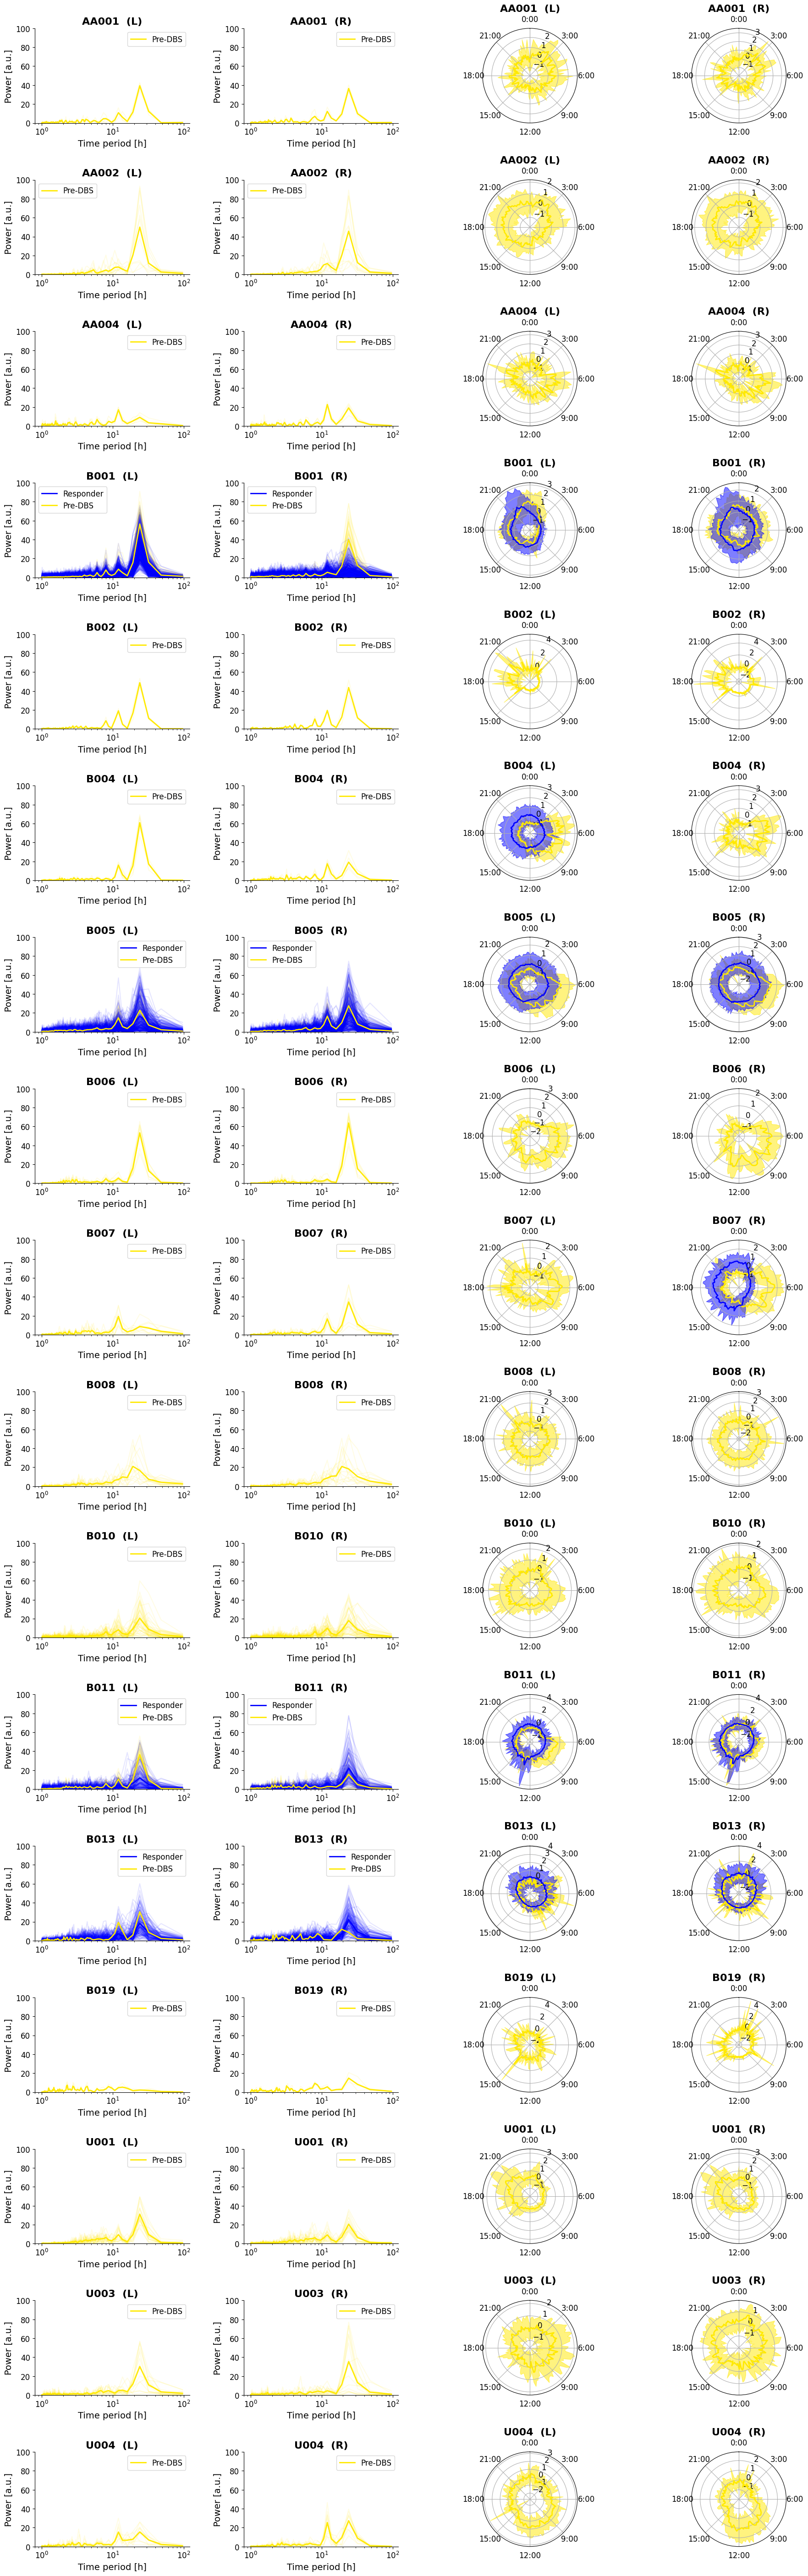

In [ ]:
TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 12
SUPTITLE_SIZE = 22
 
ROW_HEIGHT_IN = 4.2   # inches per subject row -- increase if rows feel squished
FIG_WIDTH_IN = 22     # inches, fixed width for the 4-column layout
 
plt.rcParams.update({
    "font.size": LABEL_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
})
 
subs = [s for s in df["subject"].unique() if s != "U005"]
n_subs = len(subs)
  
# One figure, one page: n_subs rows x 4 columns
# (L spectrum, R spectrum, L polar, R polar)
fig = plt.figure(figsize=(FIG_WIDTH_IN, ROW_HEIGHT_IN * n_subs))
gs = gridspec.GridSpec(n_subs, 4, figure=fig, hspace=0.6, wspace=0.35)
 
for sub_idx, sub in enumerate(subs):
    df_sub = df.query("subject == @sub")
 
    # ---- Power spectra (columns 0, 1) ----
    for lr_idx, hem in enumerate(["Pxx_left", "Pxx_right"]):
        ax = fig.add_subplot(gs[sub_idx, lr_idx])
        side = "L" if hem == "Pxx_left" else "R"
        ax.set_title(f"{sub}  ({side})", fontsize=TITLE_SIZE, fontweight="bold")
 
        resp_Pxx = []
        nonresp_Pxx = []
        preDBS_Pxx = []
        for idx, row in df_sub.iterrows():
            Pxx = row[hem]
            if isinstance(Pxx, str) is False:
                if not isinstance(Pxx, np.ndarray):
                    continue
            if math.isnan(Pxx[0]):
                continue
            responder_ = row["response"]
            if responder_ == "Responder":
                resp_Pxx.append(Pxx)
            elif responder_ == "Non-responder":
                nonresp_Pxx.append(Pxx)
            elif responder_ == "Pre-DBS":
                preDBS_Pxx.append(Pxx)
            ax.plot(time_periods, Pxx, alpha=0.1, color=COL_PAL[responder_])
 
        if nonresp_Pxx:
            nonresp_Pxx = np.array(nonresp_Pxx)
            mean_nonresp_Pxx = np.nanmean(nonresp_Pxx, axis=0)
            ax.plot(time_periods, mean_nonresp_Pxx, label="Non-Responder",
                     color=COL_PAL["Non-responder"], linewidth=2)
        if resp_Pxx:
            resp_Pxx = np.array(resp_Pxx)
            mean_resp_Pxx = np.nanmean(resp_Pxx, axis=0)
            ax.plot(time_periods, mean_resp_Pxx, label="Responder",
                     color=COL_PAL["Responder"], linewidth=2)
        if preDBS_Pxx:
            preDBS_Pxx = np.array(preDBS_Pxx)
            mean_preDBS_Pxx = np.nanmean(preDBS_Pxx, axis=0)
            ax.plot(time_periods, mean_preDBS_Pxx, label="Pre-DBS",
                     color=COL_PAL["Pre-DBS"], linewidth=2)
 
        ax.set_xscale("log")
        ax.set_ylim(0, 100)
        ax.set_xlabel("Time period [h]", fontsize=LABEL_SIZE)
        ax.set_ylabel("Power [a.u.]", fontsize=LABEL_SIZE)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.legend(fontsize=LEGEND_SIZE)
 
    # ---- Polar plots (columns 2, 3) ----
    raw_pt_df = raw_df.query("pt_id == @sub")
    for lr_idx, hem in enumerate(["left", "right"]):
        ax = fig.add_subplot(gs[sub_idx, 2 + lr_idx], projection="polar")
        side = "L" if hem == "left" else "R"
        ax.set_title(f"{sub}  ({side})", fontsize=TITLE_SIZE, fontweight="bold")
 
        mean_power = raw_pt_df.groupby(["CT_time_bin_time", "state_label_str"]).apply(
            lambda g: np.nanmean(g[f"lfp_{hem}_OvER_interpolate_z_scored"]), include_groups=False
        ).reset_index(name="lfp_mean")
        std_power = raw_pt_df.groupby(["CT_time_bin_time", "state_label_str"]).apply(
            lambda g: np.nanstd(g[f"lfp_{hem}_OvER_interpolate_z_scored"]), include_groups=False
        ).reset_index(name="lfp_std")
 
        for state in ["Pre-DBS", "Responder", "Non-responder"]:
            state_power = mean_power.query("state_label_str == @state").sort_values(
                by="CT_time_bin_time")["lfp_mean"].values
            state_std = std_power.query("state_label_str == @state").sort_values(
                by="CT_time_bin_time")["lfp_std"].values
            if len(state_power) == 0:
                continue
            ax.plot(np.linspace(0.00, 2 * np.pi, 144), state_power, color=COL_PAL[state], lw=2)
            ax.fill_between(np.linspace(0.00, 2 * np.pi, 144),
                             state_power - state_std, state_power + state_std,
                             color=COL_PAL[state], alpha=0.5)
 
        ax.set_xticks(np.linspace(0.00, 2 * np.pi, 9),
                       ["0:00", "3:00", "6:00", "9:00", "12:00", "15:00", "18:00", "21:00", ""])
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
 
#fig.suptitle("Spectra & Circadian Power by Subject", fontsize=SUPTITLE_SIZE, y=1.0 + 0.15 / n_subs)
fig.tight_layout(rect=[0, 0, 1, 1 - 0.4 / n_subs])
plt.show()